In [100]:
import numpy as np
import matplotlib.pyplot as plt

def quintic_hermite_segment(p0, p1, v0, v1, a0, a1, num_points=100):
    t = np.linspace(0, 1, num_points)
    t2 = t**2; t3 = t**3; t4 = t**4; t5 = t**5
    
    # 五次 Hermite 基函数
    h0 = -6*t5 + 15*t4 - 10*t3 + 1
    h1 = -3*t5 + 8*t4 - 6*t3 + t
    h2 = 0.5 * (-t5 + 3*t4 - 3*t3 + t2)
    h3 = 0.5 * (t5 - 2*t4 + t3)
    h4 = -3*t5 + 7*t4 - 4*t3
    h5 = 6*t5 - 15*t4 + 10*t3
    
    # 组合位置坐标
    res = (np.outer(h0, p0) + np.outer(h1, v0) + np.outer(h2, a0) + 
           np.outer(h3, a1) + np.outer(h4, v1) + np.outer(h5, p1))
    return res


In [128]:
import numpy as np
import matplotlib.pyplot as plt

# --- 数据定义 ---
pts = np.array([[0, 2], [8, 0], [10, 1.5], [12, 3]])
vel_dirs = np.array([[1, 0], [1, 0], [1, np.sqrt(3)], [1, 0]])

# 1. 计算直线距离 L
diffs = np.diff(pts, axis=0)
segment_lengths = np.sqrt(np.sum(diffs**2, axis=1))

# 2. 自动推荐模长 (基于 alpha = 0.7 的经验系数)
# 规则：每个点的模长取与其相连段长度的加权平均，或者直接参考短边
alpha = 0.9
recommended_scaling = np.zeros(len(pts))
recommended_scaling[0] = segment_lengths[0] * 0.6  # 起点
recommended_scaling[1] = min(segment_lengths[0], segment_lengths[1]) * alpha
recommended_scaling[2] = min(segment_lengths[1], segment_lengths[2]) * alpha
recommended_scaling[3] = segment_lengths[-1] * 0.5 # 终点

print(f"Recommended scaling: {np.round(recommended_scaling, 2)}")

Recommended scaling: [4.95 2.25 2.25 1.25]


In [129]:


# 模长缩放
scaling = np.round(recommended_scaling, 2)
# 最终切线向量 (V = magnitude * unit_direction)
vel_units = vel_dirs / np.linalg.norm(vel_dirs, axis=1, keepdims=True)
v_actual = vel_units * scaling[:, np.newaxis]

accels = np.zeros_like(pts)

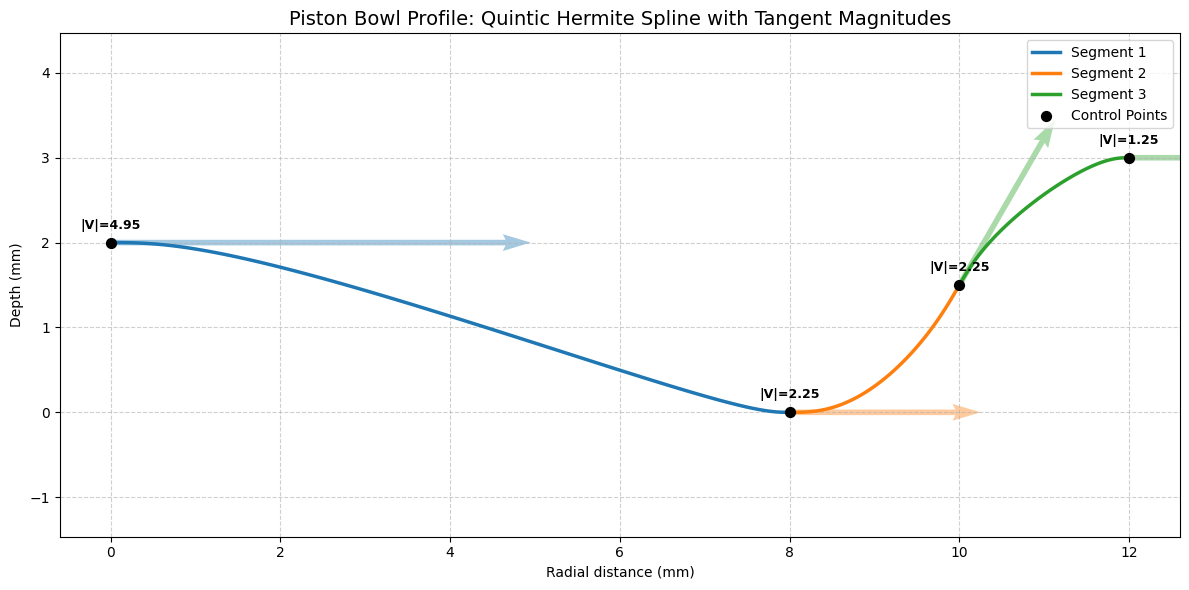

In [130]:
# --- 绘图配置 ---
plt.figure(figsize=(12, 6))
curve_segments = []

for i in range(len(pts)-1):
    # 计算当前段
    seg = quintic_hermite_segment(pts[i], pts[i+1], v_actual[i], v_actual[i+1], accels[i], accels[i+1])
    curve_segments.append(seg)
    
    # 绘制曲线段
    line, = plt.plot(seg[:,0], seg[:,1], linewidth=2.5, label=f'Segment {i+1}')
    
    # 绘制切线向量 (Quiver)
    # 起点切线
    plt.quiver(pts[i,0], pts[i,1], v_actual[i,0], v_actual[i,1], 
               angles='xy', scale_units='xy', scale=1, color=line.get_color(), 
               alpha=0.4, width=0.005, headwidth=3)
    # 终点切线 (最后一点补画)
    if i == len(pts) - 2:
        plt.quiver(pts[i+1,0], pts[i+1,1], v_actual[i+1,0], v_actual[i+1,1], 
                   angles='xy', scale_units='xy', scale=1, color=line.get_color(), 
                   alpha=0.4, width=0.005)

# 绘制控制点
plt.scatter(pts[:,0], pts[:,1], color="black", zorder=5, s=50, label='Control Points')

# 标注模长数值
for i, val in enumerate(scaling):
    plt.annotate(f'|V|={val}', (pts[i,0], pts[i,1]), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=9, fontweight='bold')

plt.title("Piston Bowl Profile: Quintic Hermite Spline with Tangent Magnitudes", fontsize=14)
plt.xlabel("Radial distance (mm)")
plt.ylabel("Depth (mm)")
plt.axis("equal")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show() 

In [131]:
pts

array([[ 0. ,  2. ],
       [ 8. ,  0. ],
       [10. ,  1.5],
       [12. ,  3. ]])